In [1]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [2]:
NUM_CLASS = 4
NUM_FEATURES = 2
RANDOM_SEED = 69

In [3]:
X_blob, y_blob = make_blobs(n_samples=1000, n_features=NUM_FEATURES, centers=NUM_CLASS, cluster_std=1.5, random_state=RANDOM_SEED)

In [4]:
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

In [9]:
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, random_state=69, test_size=0.2)

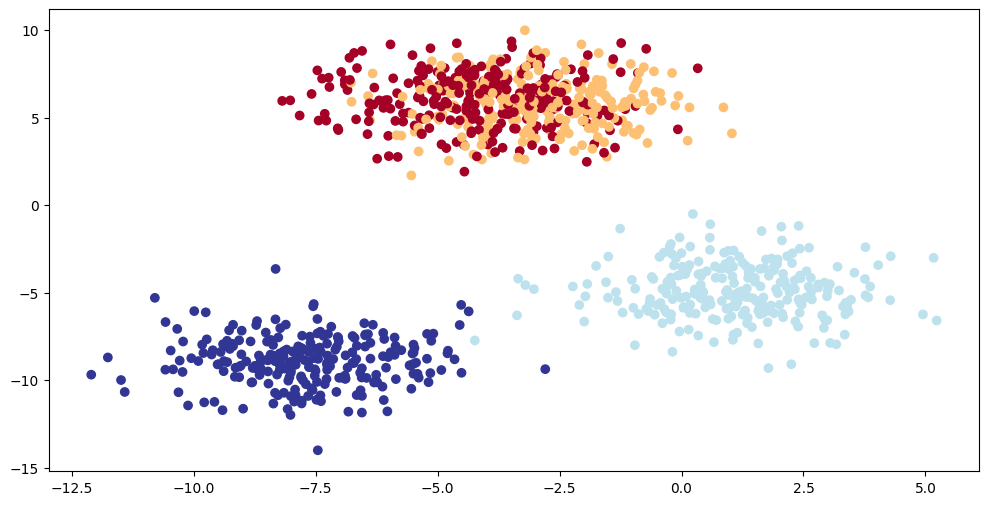

In [10]:
plt.figure(figsize=(12,6))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [30]:
from torch import nn

class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units = 8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features = hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
    def forward(self, x):
        return self.linear_layer_stack(x)

model = BlobModel(input_features=NUM_FEATURES, output_features=NUM_CLASS, hidden_units=8).to(device)
        

In [31]:
print(model)

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)


In [63]:
lossFunction = nn.CrossEntropyLoss() # Because multi class. think YOLOV5, BinaryCrossEntroyLOSS
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001)

In [64]:
model(X_blob_train.to(device))

tensor([[  1.9647,   2.0160,  -2.1421,  -2.5870],
        [-12.3067, -10.6757,   6.5759,   9.9927],
        [  1.7012,   1.9858,  -2.2312,  -2.1270],
        ...,
        [  2.0081,   1.9641,  -2.0196,  -2.7529],
        [ -8.3166,  -5.7155,   1.8303,   8.4047],
        [  1.9775,   2.0007,  -2.1059,  -2.6360]], grad_fn=<AddmmBackward0>)

In [65]:
y_logits = model(X_blob_test.to(device))
y_pred_prob = torch.softmax(y_logits, dim = 1)
print(y_logits[:5])
print(y_pred_prob[:5])

tensor([[-4.2283, -6.1936,  6.8472, -0.7265],
        [-7.5800, -6.0243,  3.1274,  6.4627],
        [ 2.0081,  1.9641, -2.0196, -2.7529],
        [ 2.0081,  1.9641, -2.0196, -2.7529],
        [-6.7893, -4.5602,  1.3330,  6.7958]], grad_fn=<SliceBackward0>)
tensor([[1.5479e-05, 2.1687e-06, 9.9947e-01, 5.1350e-04],
        [7.6936e-07, 3.6456e-06, 3.4381e-02, 9.6561e-01],
        [5.0421e-01, 4.8249e-01, 8.9820e-03, 4.3146e-03],
        [5.0421e-01, 4.8249e-01, 8.9820e-03, 4.3146e-03],
        [1.2538e-06, 1.1650e-05, 4.2238e-03, 9.9576e-01]],
       grad_fn=<SliceBackward0>)


In [66]:
torch.sum(y_pred_prob[0])

tensor(1., grad_fn=<SumBackward0>)

In [67]:
print(y_pred_prob[0])
print(torch.argmax(y_pred_prob[0]))

tensor([1.5479e-05, 2.1687e-06, 9.9947e-01, 5.1350e-04],
       grad_fn=<SelectBackward0>)
tensor(2)


In [68]:
torch.manual_seed(100)

In [69]:
epochs = 1000

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

In [70]:
def accuracyFunction(yTrue, yPred):
    correct = torch.eq(yTrue, yPred).sum().item()
    acc = (correct/len(yPred)) * 100
    return acc

In [72]:
for epoch in range(epochs):
    model.train()

    y_logits = model(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    
    loss = lossFunction(y_logits, y_blob_train)
    
    train_acc = accuracyFunction(yTrue = y_blob_train, yPred = y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_blob_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        
        test_acc = accuracyFunction(yTrue = y_blob_test, yPred = test_pred)
        test_loss = lossFunction(test_logits, y_blob_test)

        if epoch % 2 == 0:
            print(f"Epoch:{epoch} || Loss:{loss:.5f} || Train Accuracy:{train_acc:.2f} || Test Loss = {test_loss:.5f} || Test Accuracy:{test_acc:.2f}")

Epoch:0 || Loss:0.36313 || Train Accuracy:80.00 || Test Loss = 0.37625 || Test Accuracy:72.50
Epoch:2 || Loss:0.36313 || Train Accuracy:80.00 || Test Loss = 0.37625 || Test Accuracy:72.50
Epoch:4 || Loss:0.36313 || Train Accuracy:80.00 || Test Loss = 0.37625 || Test Accuracy:72.50
Epoch:6 || Loss:0.36313 || Train Accuracy:80.00 || Test Loss = 0.37625 || Test Accuracy:72.50
Epoch:8 || Loss:0.36312 || Train Accuracy:80.00 || Test Loss = 0.37624 || Test Accuracy:72.50
Epoch:10 || Loss:0.36312 || Train Accuracy:80.00 || Test Loss = 0.37624 || Test Accuracy:72.50
Epoch:12 || Loss:0.36312 || Train Accuracy:80.00 || Test Loss = 0.37624 || Test Accuracy:72.50
Epoch:14 || Loss:0.36312 || Train Accuracy:80.00 || Test Loss = 0.37624 || Test Accuracy:72.50
Epoch:16 || Loss:0.36311 || Train Accuracy:80.00 || Test Loss = 0.37624 || Test Accuracy:72.50
Epoch:18 || Loss:0.36311 || Train Accuracy:80.00 || Test Loss = 0.37624 || Test Accuracy:72.50
Epoch:20 || Loss:0.36311 || Train Accuracy:80.00 || Tes